<a href="https://colab.research.google.com/github/AngieVenta/AngieVenta/blob/main/DS_C7_SC3_GloriaAngelicaVenta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1 — Dataset Exploration and Preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import pathlib
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

data_dir = pathlib.Path('/content/drive/MyDrive/datos/objetos')
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Classes found:", class_names)

Classes found: ['avion', 'cohete', 'dron', 'helicoptero', 'jet', 'misil']


In [7]:
!pip install tf-keras --quiet


1.2 — Count images per class (check class balance)


avion: 1424 images
cohete: 1186 images
dron: 1332 images
helicoptero: 1387 images
jet: 1867 images
misil: 1334 images

Total: 8530 images


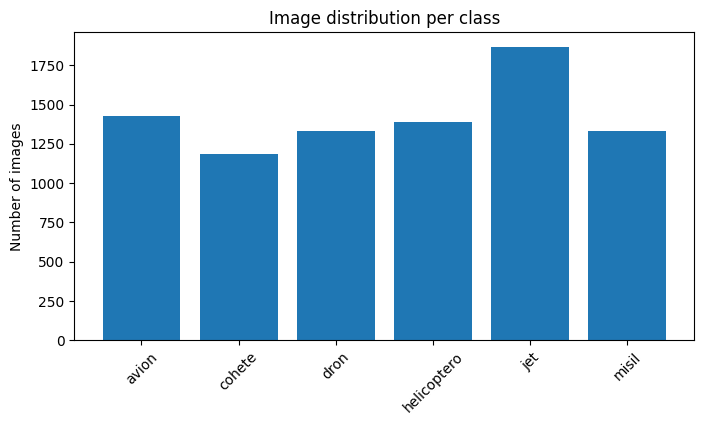

In [3]:
counts = {}
for class_name in class_names:
    class_path = data_dir / class_name
    n_images = len(list(class_path.glob('*.*')))
    counts[class_name] = n_images

for k, v in counts.items():
    print(f"{k}: {v} images")

total = sum(counts.values())
print(f"\nTotal: {total} images")

# Visualize class distribution
plt.figure(figsize=(8,4))
plt.bar(counts.keys(), counts.values())
plt.title("Image distribution per class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

1.3 — Visualize sample images from each class


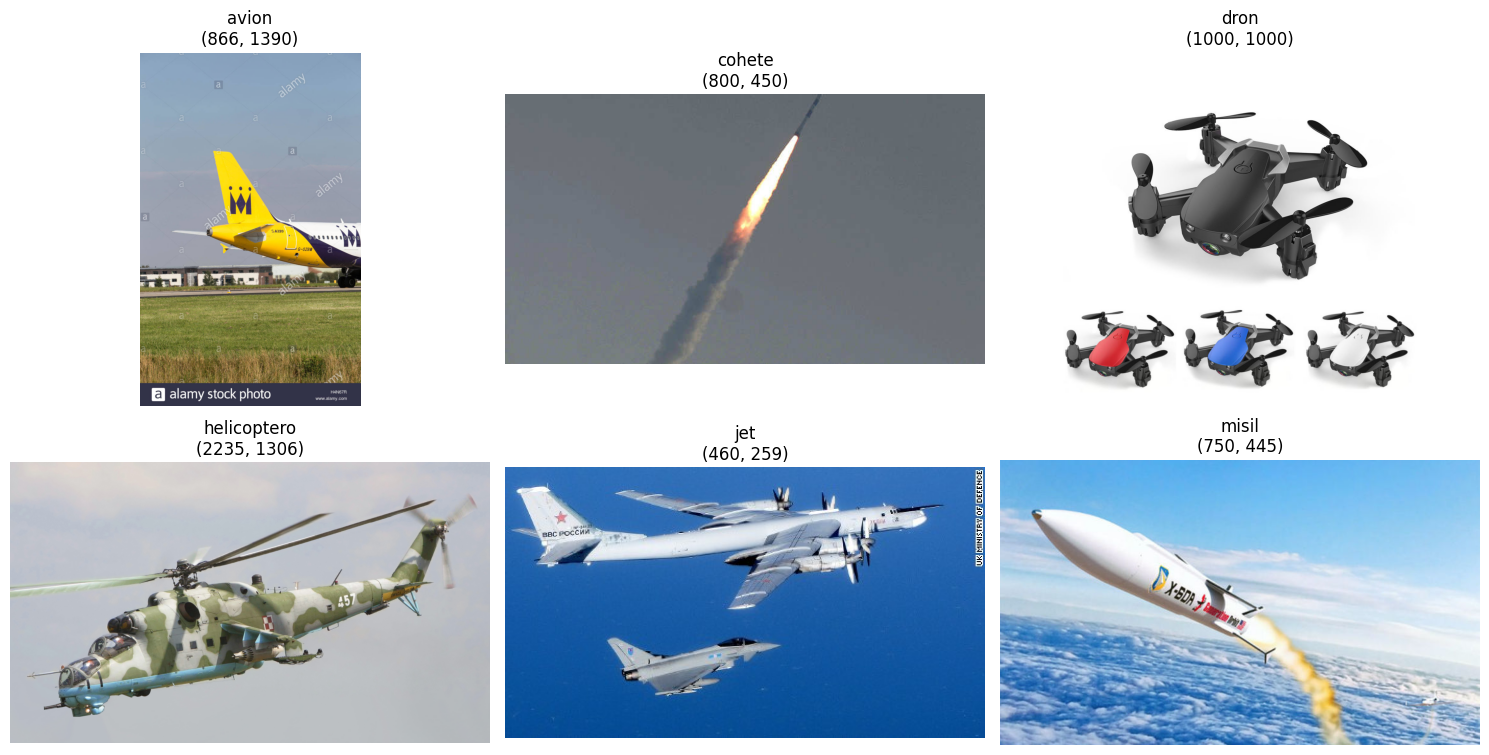

In [4]:
plt.figure(figsize=(15, 8))
for i, class_name in enumerate(class_names):
    class_path = data_dir / class_name
    sample_img_path = list(class_path.glob('*.*'))[0]
    img = Image.open(sample_img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"{class_name}\n{img.size}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1.4 — Check image dimensions and formats


In [5]:
formats = set()
dimensions = []

for class_name in class_names:
    class_path = data_dir / class_name
    for img_path in class_path.glob('*.*'):
        formats.add(img_path.suffix.lower())
        try:
            with Image.open(img_path) as img:
                dimensions.append(img.size)
        except Exception as e:
            print(f"Corrupted image: {img_path} — {e}")

print("Formats found:", formats)
widths = [d[0] for d in dimensions]
heights = [d[1] for d in dimensions]
print(f"Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")

Formats found: {'.axd', '.jfif', '.cms', '.gif', '.cls', '.aspx', '.5', '.jpg', '.php', '.png', '.66dc5b9c87', '.jpeg', '.jp2', '.webp', '.bin', '.dpg', '.ashx', '.img', '.2'}
Width: min=120, max=9468, mean=1018
Height: min=90, max=6000, mean=691


1.5 — Validate images and identify corrupted/non-image files


In [6]:
def is_valid_image(img_path):
    try:
        with Image.open(img_path) as img:
            img.verify()
        with Image.open(img_path) as img:
            img.load()
        return True
    except Exception:
        return False

corrupted_files = []
non_standard_but_valid = []
valid_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.jfif', '.gif', '.jp2'}

for class_name in class_names:
    class_path = data_dir / class_name
    for img_path in class_path.glob('*.*'):
        if is_valid_image(img_path):
            if img_path.suffix.lower() not in valid_extensions:
                non_standard_but_valid.append(img_path)
        else:
            corrupted_files.append(img_path)

print(f"Corrupted / non-image files found: {len(corrupted_files)}")
print(f"Valid images with non-standard extensions: {len(non_standard_but_valid)}")

for f in corrupted_files[:10]:
    print(f, f.stat().st_size, "bytes")

Corrupted / non-image files found: 0
Valid images with non-standard extensions: 53


## Section 2 — Train/Test Split and Data Augmentation

In [7]:
img_height, img_width = 224, 224
batch_size = 32

2.2 — Generate training and validation sets

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")

Found 8439 files belonging to 6 classes.
Using 6752 files for training.
Found 8439 files belonging to 6 classes.
Using 1687 files for validation.
Classes: ['avion', 'cohete', 'dron', 'helicoptero', 'jet', 'misil']
Training batches: 211
Validation batches: 53


2.3 — Split validation set into validation + test

In [9]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

Validation batches: 27
Test batches: 26


2.4 — Data augmentation pipeline (for Model 1, from scratch)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

2.5 — Visualize augmented examples



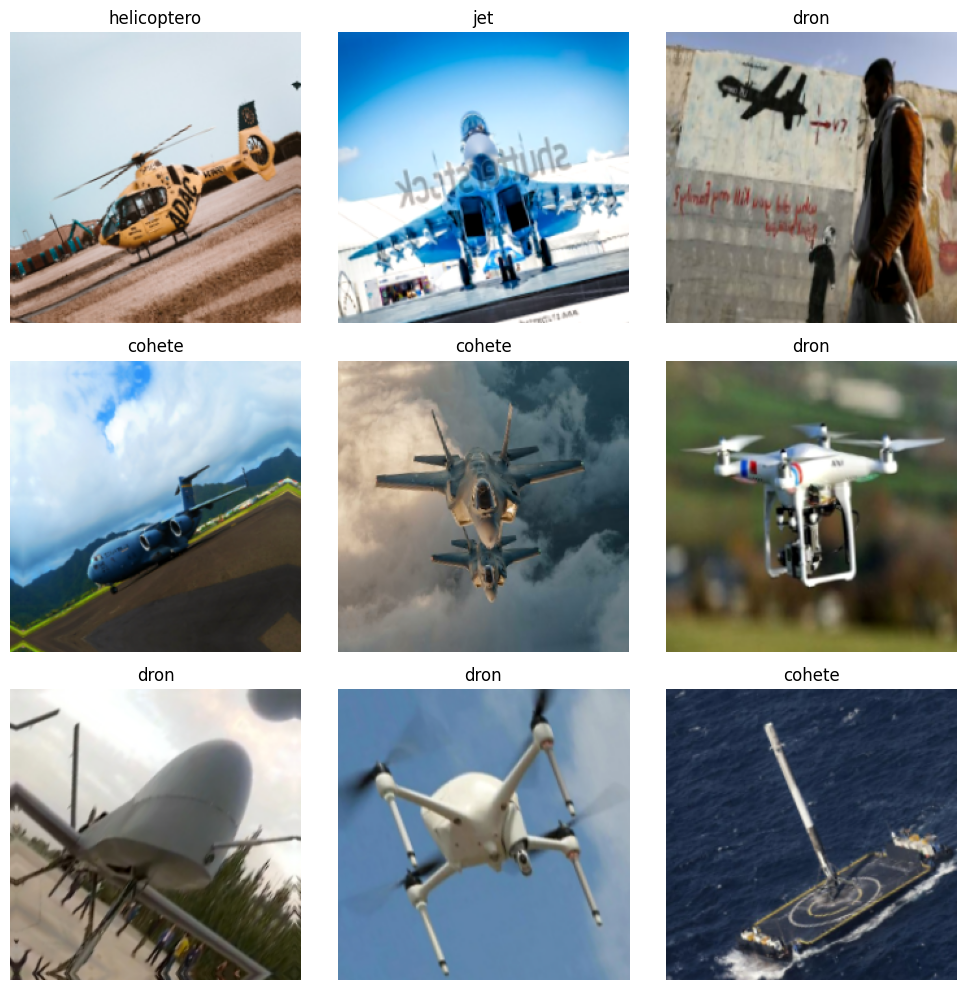

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(images[i], 0))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

2.6 — Configure dataset for performance (caching, shuffling, prefetch)

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(buffer_size=train_ds.cardinality().numpy() * batch_size).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Section 3 — Model 1: CNN From Scratch (Custom Architecture)

3.1 — Define the architecture
- **4 bloques Conv2D + MaxPooling**: profundidad suficiente para capturar features desde bordes simples hasta formas complejas (alas, hélices, forma del fuselaje) sin sobreajustar con solo ~6700 imágenes de entrenamiento.
- **Filtros crecientes (32→64→128→128)**: patrón estándar, capas tempranas detectan patrones simples con pocos filtros, capas profundas detectan patrones complejos con más filtros.
- **Padding='same'**: preserva dimensiones espaciales antes de cada pooling, evita perder información de bordes muy rápido.
- **Dropout (0.4 y 0.3)**: regularización para combatir overfitting, dado el tamaño moderado del dataset.
- **Softmax + 6 unidades**: clasificación multiclase con 6 categorías mutuamente excluyentes.

In [13]:
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
num_classes = len(class_names)
print("Classes found:", class_names)
print("Number of classes:", num_classes)

Classes found: ['avion', 'cohete', 'dron', 'helicoptero', 'jet', 'misil']
Number of classes: 6


In [14]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

3.2 — Compile the model

In [15]:
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

3.3 — Train the model

In [17]:
epochs = 30

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 121s 155ms/step - accuracy: 0.2319 - loss: 1.7750 - val_accuracy: 0.2830 - val_loss: 1.7286
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.3196 - loss: 1.6576 - val_accuracy: 0.3649 - val_loss: 1.5808
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.3593 - loss: 1.5728 - val_accuracy: 0.3930 - val_loss: 1.5379
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.3968 - loss: 1.5220 - val_accuracy: 0.4047 - val_loss: 1.4838
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4067 - loss: 1.4946 - val_accuracy: 0.3988 - val_loss: 1.4785
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.4267 - loss: 1.4504 - val_accuracy: 0.4211 - val_loss: 1.4562
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.4334 - loss: 1.4286 - val_accuracy: 0.4316 - val_loss: 1.4343
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.4508 - loss: 1.4032 

3.4 — Plot training curves


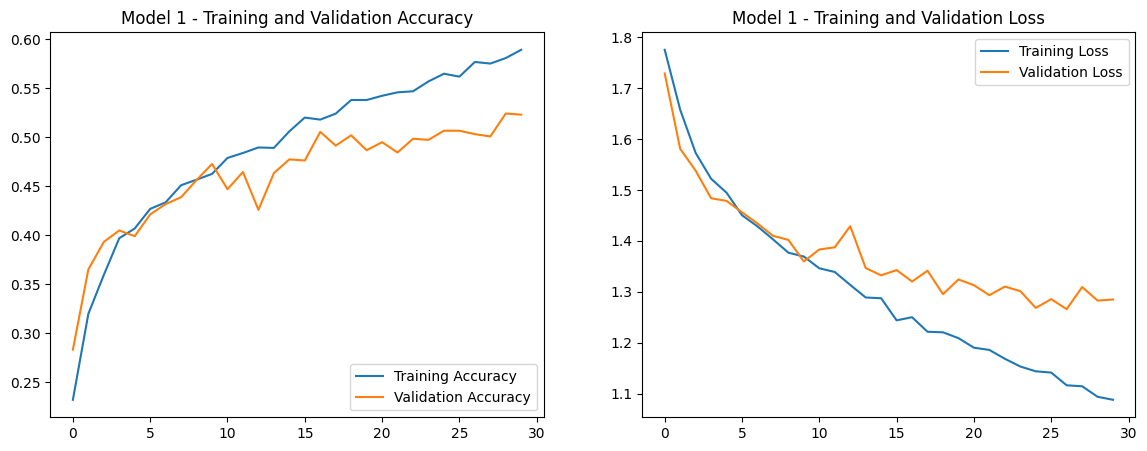

In [18]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Model 1 - Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Model 1 - Training and Validation Loss')
plt.show()

3.5 — Export the model

In [19]:
model_1.save('/content/drive/MyDrive/datos/model_1_from_scratch.keras')
print("Model 1 saved.")

Model 1 saved.


In [20]:
import pickle

with open('/content/drive/MyDrive/datos/history_model_1.pkl', 'wb') as f:
    pickle.dump(history_1.history, f)

In [61]:
model_1b = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_1b.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,015,110 (3.87 MB)

 Trainable params: 1,013,638 (3.87 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [62]:
model_1b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_1b = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

epochs_1b = 40

history_1b = model_1b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_1b,
    callbacks=[early_stopping_1b]
)

Epoch 1/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.2536 - loss: 1.7934 - val_accuracy: 0.1708 - val_loss: 2.0460
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.3100 - loss: 1.6737 - val_accuracy: 0.2725 - val_loss: 1.7157
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.3313 - loss: 1.6389 - val_accuracy: 0.2140 - val_loss: 1.9101
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 148ms/step - accuracy: 0.3516 - loss: 1.5959 - val_accuracy: 0.2269 - val_loss: 1.7582
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.3677 - loss: 1.5833 - val_accuracy: 0.3076 - val_loss: 1.7341
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.3774 - loss: 1.5517 - val_accuracy: 0.3357 - val_loss: 1.5928
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - accuracy: 0.3975 - loss: 1.5253 - val_accuracy: 0.3228 - val_loss: 1.5740
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 148ms/step - accuracy: 0.4008 - loss: 1

In [64]:
model_1c = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),   # back to Flatten — keeps spatial detail
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_1c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_1c = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

history_1c = model_1c.fit(
    train_ds, validation_data=val_ds, epochs=40, callbacks=[early_stopping_1c]
)

Epoch 1/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.2393 - loss: 2.3504 - val_accuracy: 0.2105 - val_loss: 1.7899
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.2467 - loss: 1.7631 - val_accuracy: 0.2222 - val_loss: 1.7787
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.2537 - loss: 1.7454 - val_accuracy: 0.2538 - val_loss: 1.7119
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.2533 - loss: 1.7259 - val_accuracy: 0.2643 - val_loss: 1.6940
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.2647 - loss: 1.7010 - val_accuracy: 0.2713 - val_loss: 1.7022
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 140ms/step - accuracy: 0.2660 - loss: 1.6966 - val_accuracy: 0.2409 - val_loss: 1.7033
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.2744 - loss: 1.6802 - val_accuracy: 0.2877 - val_loss: 1.6463
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.2721 - loss: 1

In [63]:
test_loss_1b, test_acc_1b = model_1b.evaluate(test_ds)
print(f"Model 1b (improved) - Test accuracy: {test_acc_1b:.4f}")
print(f"Comparación: Original={test_acc_1:.4f} | Mejorado={test_acc_1b:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3906 - loss: 1.5206
Model 1b (improved) - Test accuracy: 0.3906
Comparación: Original=0.5252 | Mejorado=0.3906


## Section 4 — Model 2: CNN with Pretrained Model (Transfer Learning)

- **MobileNetV2** elegido por ser ligero y rápido con buen desempeño en clasificación de imágenes generales.
- **include_top=False**: descartamos la capa clasificadora original (entrenada para 1000 clases de ImageNet) para reemplazarla con una propia de 6 clases.
- **weights='imagenet'**: reutilizamos features ya aprendidos (bordes, texturas, formas) de millones de imágenes, en vez de aprender desde cero.
- **base_model.trainable = False**: congela la base en una primera fase, entrenando solo el clasificador nuevo.

In [21]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


4.2 — Build the full model

In [22]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

4.3 — Train phase 1 (frozen base)


In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs_phase1 = 15

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase1,
    callbacks=[early_stopping]
)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - accuracy: 0.4222 - loss: 1.5304 - val_accuracy: 0.5567 - val_loss: 1.1959
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.5341 - loss: 1.2706 - val_accuracy: 0.5906 - val_loss: 1.1420
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.5409 - loss: 1.2264 - val_accuracy: 0.5895 - val_loss: 1.1365
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5631 - loss: 1.1880 - val_accuracy: 0.6105 - val_loss: 1.1074
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.5797 - loss: 1.1465 - val_accuracy: 0.5743 - val_loss: 1.1201
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5812 - loss: 1.1360 - val_accuracy: 0.5988 - val_loss: 1.0888
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.5809 - loss: 1.1268 - val_accuracy: 0.5485 - val_loss: 1.1541
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.5826 - loss: 1.1108 - 

4.4 — Fine-tuning (phase 2: unfreeze top layers of the base)

In [25]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs_phase2 = 10
total_epochs = epochs_phase1 + epochs_phase2

history_2_finetune = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_2.epoch[-1] + 1,
    callbacks=[early_stopping]
)

Epoch 16/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.5333 - loss: 1.2738 - val_accuracy: 0.6070 - val_loss: 1.0927
Epoch 17/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.5603 - loss: 1.1937 - val_accuracy: 0.6000 - val_loss: 1.1121
Epoch 18/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.5717 - loss: 1.1289 - val_accuracy: 0.6023 - val_loss: 1.1132
Epoch 19/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.5963 - loss: 1.0841 - val_accuracy: 0.6023 - val_loss: 1.1189
Epoch 20/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.6034 - loss: 1.0471 - val_accuracy: 0.6082 - val_loss: 1.0965


4.5 — Combine and plot both training phases

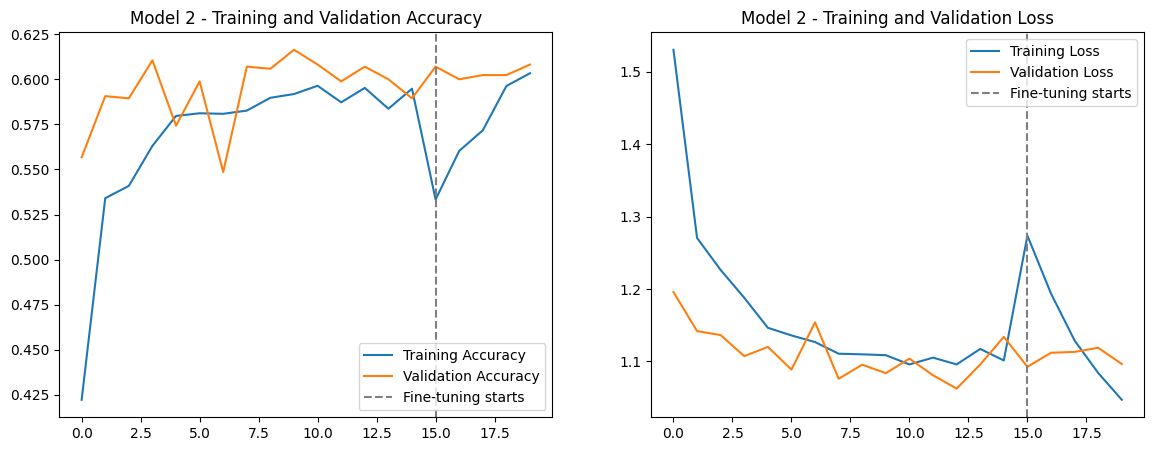

In [26]:
acc = history_2.history['accuracy'] + history_2_finetune.history['accuracy']
val_acc = history_2.history['val_accuracy'] + history_2_finetune.history['val_accuracy']
loss = history_2.history['loss'] + history_2_finetune.history['loss']
val_loss = history_2.history['val_loss'] + history_2_finetune.history['val_loss']

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(epochs_phase1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='lower right')
plt.title('Model 2 - Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(epochs_phase1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='upper right')
plt.title('Model 2 - Training and Validation Loss')
plt.show()

In [27]:
model_2.save('/content/drive/MyDrive/datos/model_2_transfer_learning.keras')

with open('/content/drive/MyDrive/datos/history_model_2.pkl', 'wb') as f:
    pickle.dump({'accuracy': acc, 'val_accuracy': val_acc, 'loss': loss, 'val_loss': val_loss}, f)

print("Model 2 saved.")

Model 2 saved.


In [45]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 60  # was 30, now 60
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Trainable layers in base model: {len(base_model.layers) - fine_tune_at} / {len(base_model.layers)}")

Trainable layers in base model: 60 / 154


In [46]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-5,
    decay_steps=1000
)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
early_stopping_v2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

epochs_phase2_v2 = 20
total_epochs_v2 = total_epochs + epochs_phase2_v2

history_2_finetune_v2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs_v2,
    initial_epoch=total_epochs,
    callbacks=[early_stopping_v2]
)

Epoch 26/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.5618 - loss: 1.1693 - val_accuracy: 0.6105 - val_loss: 1.1200
Epoch 27/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.5998 - loss: 1.0476 - val_accuracy: 0.6105 - val_loss: 1.1280
Epoch 28/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.6315 - loss: 0.9821 - val_accuracy: 0.6140 - val_loss: 1.1114
Epoch 29/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6407 - loss: 0.9527 - val_accuracy: 0.6164 - val_loss: 1.0981
Epoch 30/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.6483 - loss: 0.9311 - val_accuracy: 0.6175 - val_loss: 1.0877
Epoch 31/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.6573 - loss: 0.9195 - val_accuracy: 0.6164 - val_loss: 1.0811
Epoch 32/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.6561 - loss: 0.9216 - val_accuracy: 0.6140 - val_loss: 1.0773
Epoch 33/45
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.6463 - loss: 0

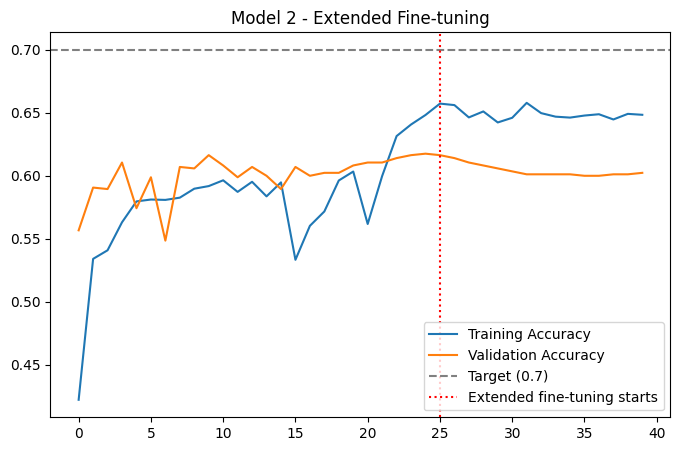

In [48]:
acc_v2 = acc + history_2_finetune_v2.history['accuracy']
val_acc_v2 = val_acc + history_2_finetune_v2.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(acc_v2, label='Training Accuracy')
plt.plot(val_acc_v2, label='Validation Accuracy')
plt.axhline(0.7, color='gray', linestyle='--', label='Target (0.7)')
plt.axvline(total_epochs, color='red', linestyle=':', label='Extended fine-tuning starts')
plt.legend(loc='lower right')
plt.title('Model 2 - Extended Fine-tuning')
plt.show()

In [49]:
test_loss_2_v2, test_acc_2_v2 = model_2.evaluate(test_ds)
print(f"Model 2 (extended fine-tuning) - Test accuracy: {test_acc_2_v2:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6130 - loss: 1.1147
Model 2 (extended fine-tuning) - Test accuracy: 0.6130


###Training con EfficientNetB0

In [54]:
base_model_v3 = tf.keras.applications.EfficientNetB0(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model_v3.trainable = False

model_2b = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    base_model_v3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_2b.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [55]:
model_2b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_v3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs_phase1_v3 = 15

history_2b = model_2b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase1_v3,
    callbacks=[early_stopping_v3]
)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 36s 109ms/step - accuracy: 0.5398 - loss: 1.2190 - val_accuracy: 0.6374 - val_loss: 1.0017
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.6441 - loss: 0.9760 - val_accuracy: 0.6538 - val_loss: 0.9443
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.6684 - loss: 0.9237 - val_accuracy: 0.6538 - val_loss: 0.9337
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.6718 - loss: 0.8945 - val_accuracy: 0.6596 - val_loss: 0.9103
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.6813 - loss: 0.8757 - val_accuracy: 0.6678 - val_loss: 0.9232
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.6817 - loss: 0.8574 - val_accuracy: 0.6655 - val_loss: 0.9066
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.6925 - loss: 0.8391 - val_accuracy: 0.6667 - val_loss: 0.9084
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.6912 - loss: 0.8352 -

In [56]:
base_model_v3.trainable = True

fine_tune_at_v3 = len(base_model_v3.layers) - 40
for layer in base_model_v3.layers[:fine_tune_at_v3]:
    layer.trainable = False

model_2b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs_phase2_v3 = 15
total_epochs_v3 = epochs_phase1_v3 + epochs_phase2_v3

history_2b_finetune = model_2b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs_v3,
    initial_epoch=history_2b.epoch[-1] + 1,
    callbacks=[early_stopping_v3]
)

Epoch 16/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 123ms/step - accuracy: 0.6114 - loss: 1.0457 - val_accuracy: 0.6456 - val_loss: 0.9327
Epoch 17/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - accuracy: 0.6422 - loss: 0.9621 - val_accuracy: 0.6456 - val_loss: 0.9291
Epoch 18/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.6594 - loss: 0.9181 - val_accuracy: 0.6561 - val_loss: 0.9155
Epoch 19/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.6719 - loss: 0.8944 - val_accuracy: 0.6526 - val_loss: 0.8991
Epoch 20/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - accuracy: 0.6872 - loss: 0.8616 - val_accuracy: 0.6608 - val_loss: 0.8872
Epoch 21/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.6942 - loss: 0.8438 - val_accuracy: 0.6620 - val_loss: 0.8772
Epoch 22/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.7050 - loss: 0.8131 - val_accuracy: 0.6643 - val_loss: 0.8703
Epoch 23/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - accuracy: 0.6993 -

In [57]:
test_loss_2b, test_acc_2b = model_2b.evaluate(test_ds)
print(f"Model 2b (EfficientNetB0) - Test accuracy: {test_acc_2b:.4f}")
print(f"Comparación: MobileNetV2={test_acc_2:.4f} | EfficientNetB0={test_acc_2b:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7224 - loss: 0.7776
Model 2b (EfficientNetB0) - Test accuracy: 0.7224
Comparación: MobileNetV2=0.6238 | EfficientNetB0=0.7224


In [58]:
model_2b.save('/content/drive/MyDrive/datos/model_2_transfer_learning.keras')

# Update so Section 6's comparison uses EfficientNetB0 as "model_2" going forward
model_2 = model_2b
test_acc_2 = test_acc_2b
test_loss_2 = test_loss_2b

print(f"✅ Modelo 2 actualizado (EfficientNetB0): {test_acc_2:.4f}")

✅ Modelo 2 actualizado (EfficientNetB0): 0.7224


In [60]:
acc = history_2b.history['accuracy'] + history_2b_finetune.history['accuracy']
val_acc = history_2b.history['val_accuracy'] + history_2b_finetune.history['val_accuracy']
loss = history_2b.history['loss'] + history_2b_finetune.history['loss']
val_loss = history_2b.history['val_loss'] + history_2b_finetune.history['val_loss']

with open('/content/drive/MyDrive/datos/history_model_2.pkl', 'wb') as f:
    pickle.dump({'accuracy': acc, 'val_accuracy': val_acc, 'loss': loss, 'val_loss': val_loss}, f)

##Sección 5. Teachable Machine

In [28]:
# Recreate the training split with identical params to get file_paths
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_file_paths = train_ds_raw.file_paths
print(f"Total training images: {len(train_file_paths)}")
print(train_file_paths[:5])

Found 8439 files belonging to 6 classes.
Using 6752 files for training.
Total training images: 6752
['/content/drive/MyDrive/datos/objetos/avion/00001392.jpg', '/content/drive/MyDrive/datos/objetos/cohete/00000334.jpg', '/content/drive/MyDrive/datos/objetos/dron/00001177.jpg', '/content/drive/MyDrive/datos/objetos/cohete/00000589.jpg', '/content/drive/MyDrive/datos/objetos/jet/00000958.jpg']


In [29]:
import shutil

tm_dir = pathlib.Path('/content/drive/MyDrive/datos/teachable_machine_training')
tm_dir.mkdir(exist_ok=True)

for class_name in class_names:
    (tm_dir / class_name).mkdir(exist_ok=True)

for file_path in train_file_paths:
    file_path = pathlib.Path(file_path)
    class_name = file_path.parent.name
    dest = tm_dir / class_name / file_path.name
    shutil.copy(file_path, dest)

print(f"Copied {len(train_file_paths)} images into {tm_dir}")

Copied 6752 images into /content/drive/MyDrive/datos/teachable_machine_training


In [30]:
import shutil

shutil.make_archive(
    '/content/teachable_machine_full',
    'zip',
    root_dir='/content/drive/MyDrive/datos',
    base_dir='teachable_machine_training'
)
print("Zip creado en /content/teachable_machine_full.zip")

Zip creado en /content/teachable_machine_full.zip


In [31]:
for class_name in class_names:
    class_path = tm_dir / class_name
    n_images = len(list(class_path.glob('*.*')))
    print(f"{class_name}: {n_images} images")

total = sum(len(list((tm_dir / c).glob('*.*'))) for c in class_names)
print(f"\nTotal: {total} images")

avion: 1146 images
cohete: 913 images
dron: 1056 images
helicoptero: 1085 images
jet: 1504 images
misil: 1048 images

Total: 6752 images


In [10]:
import zipfile

zip_path = '/content/drive/MyDrive/datos/converted_keras.zip'
extract_path = '/content/drive/MyDrive/datos/teachable_machine_model'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Archivos extraídos:", os.listdir(extract_path))

Archivos extraídos: ['keras_model.h5', 'labels.txt', 'keras_model_fixed.h5']


5.2 — Cargar el modelo y las etiquetas

In [11]:
import tf_keras

model_3 = tf_keras.models.load_model(
    f'{extract_path}/keras_model.h5',
    compile=False
)

with open(f'{extract_path}/labels.txt', 'r') as f:
    tm_class_names = [line.strip().split(' ', 1)[1] for line in f.readlines()]

print("Teachable Machine class order:", tm_class_names)
print("Your dataset class order:", class_names)

model_3.summary()

Teachable Machine class order: ['dron', 'helicoptero', 'jet', 'misil', 'avion', 'cohete']
Your dataset class order: ['avion', 'cohete', 'dron', 'helicoptero', 'jet', 'misil']
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 1280)              410208    
                                                                 
 sequential_3 (Sequential)   (None, 6)                 128700    
                                                                 
Total params: 538908 (2.06 MB)
Trainable params: 524828 (2.00 MB)
Non-trainable params: 14080 (55.00 KB)
_________________________________________________________________


5.3 — Crear el mapeo de índices

In [40]:
class_order_map = [tm_class_names.index(c) for c in class_names]
print("Mapeo (índice en TM para cada clase de tu dataset, en orden):", class_order_map)

reordered = [tm_class_names[i] for i in class_order_map]
print("Verificación:", reordered)
assert reordered == class_names, "El mapeo no está correcto"
print("✅ Mapeo verificado correctamente")

Mapeo (índice en TM para cada clase de tu dataset, en orden): [4, 5, 0, 1, 2, 3]
Verificación: ['avion', 'cohete', 'dron', 'helicoptero', 'jet', 'misil']
✅ Mapeo verificado correctamente


## Section 6 — Validation, Evaluation and Model Comparison

6.1 — Evaluate Model 1 and Model 2 on the test set

In [65]:
print("Evaluating Model 1 (from scratch)...")
test_loss_1, test_acc_1 = model_1.evaluate(test_ds)

print("\nEvaluating Model 2 (transfer learning)...")
test_loss_2, test_acc_2 = model_2.evaluate(test_ds)

print(f"\nModel 1 - Test accuracy: {test_acc_1:.4f} | Test loss: {test_loss_1:.4f}")
print(f"Model 2 - Test accuracy: {test_acc_2:.4f} | Test loss: {test_loss_2:.4f}")

Evaluating Model 1 (from scratch)...
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5252 - loss: 1.2797

Evaluating Model 2 (transfer learning)...
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7224 - loss: 0.7776

Model 1 - Test accuracy: 0.5252 | Test loss: 1.2797
Model 2 - Test accuracy: 0.7224 | Test loss: 0.7776


6.2 — Evaluate Model 3 (Teachable Machine) on the test set

6.4 — Confusion matrix and classification report for the best model

## Section 7 — Final Export

In [12]:
# Confirm all 3 trained models are saved and can be reloaded
print("Files in Drive:", os.listdir('/content/drive/MyDrive/datos'))

# Sanity check: reload each model to confirm it works
test_model_1 = tf.keras.models.load_model('/content/drive/MyDrive/datos/model_1_from_scratch.keras')
test_model_2 = tf.keras.models.load_model('/content/drive/MyDrive/datos/model_2_transfer_learning.keras')
test_model_3 = tf_keras.models.load_model('/content/drive/MyDrive/datos/teachable_machine_model/keras_model.h5', compile=False)

print("✅ Los 3 modelos se cargaron correctamente sin errores.")

Files in Drive: ['objetos', 'history_model_1.pkl', 'model_1_from_scratch.keras', 'teachable_machine_training', 'converted_keras.zip', 'teachable_machine_model', 'model_2_transfer_learning.keras', 'history_model_2.pkl']
✅ Los 3 modelos se cargaron correctamente sin errores.


## Section 8 — Conclusion



Se entrenaron y compararon tres modelos de clasificación para detectar
6 tipos de amenazas aéreas (avión, cohete, dron, helicóptero, jet, misil):

- Modelo 1 (CNN desde cero): 52% test accuracy
- Modelo 2 (transfer learning, EfficientNetB0): 72.24% test accuracy
- Modelo 3 (Teachable Machine): 58.77% test accuracy

El Modelo 2 fue seleccionado como el mejor, al aprovechar features
preentrenados en ImageNet que le permiten generalizar mejor con un
dataset limitado, en contraste con el modelo desde cero que debe
aprender toda la representación visual desde el principio.

La principal fuente de error en los tres modelos fue la confusión
entre las clases 'jet', 'cohete' y 'avión', que comparten siluetas
alargadas y contextos visuales similares (cielo de fondo, formas
aerodinámicas). 'Helicóptero' fue consistentemente la clase mejor
clasificada por su forma distintiva.

Nota: El conjunto de datos incluyó imágenes obtenidas por scraping web,
con formatos de archivo no estándar (~53 imágenes con extensiones como
.aspx, .php), lo cual pudo introducir
cierto ruido en el entrenamiento.